# 🧠 LSTM-Based Text Sequence Prediction System
### Lab Assignment 5 — Deep Learning

**Group Assignment | Task 1: Text Prediction**

Group Members :
1. Shubhangi Bapurao Takik
2. Sneha Nannaware
3. Gauri Kale
4. Vedika Gurav

**Dataset:** Wikipedia API (fetches real articles dynamically)

**Deployment:** FastAPI `/predict` endpoint + n8n WhatsApp Agent

---
### 📌 LSTM Mathematical Model

An LSTM cell processes sequences using 4 key components:

**Forget Gate** — decides what to throw away from cell state:
$$f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f)$$

**Input Gate** — decides what new info to store:
$$i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i)$$
$$\tilde{C}_t = \tanh(W_C \cdot [h_{t-1}, x_t] + b_C)$$

**Cell State Update** — combines forget and input:
$$C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t$$

**Output Gate** — decides what to output:
$$o_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o)$$
$$h_t = o_t \odot \tanh(C_t)$$

Where:
- $\sigma$ = sigmoid activation
- $\odot$ = element-wise multiplication
- $x_t$ = input at time step t
- $h_t$ = hidden state (short-term memory)
- $C_t$ = cell state (long-term memory)

## Step 1: Install Dependencies

In [ ]:
!pip install wikipedia-api tensorflow numpy scikit-learn joblib fastapi uvicorn nest-asyncio pyngrok requests -q

## Step 2: Dataset Collection via Wikipedia API

In [2]:
import wikipediaapi
import re

# --- Dataset Declaration ---
# Dataset Name: Wikipedia Articles
# Source: https://en.wikipedia.org
# API: wikipedia-api Python library
# Description: Text content from multiple Wikipedia articles on AI/ML topics
# Preprocessing: Lowercased, punctuation removed, tokenized into sequences of 40 words

wiki = wikipediaapi.Wikipedia(
    language='en',
    user_agent='LSTMAssignment/1.0 (student-project)'
)

topics = [
    'Machine learning',
    'Artificial intelligence',
    'Deep learning',
    'Neural network',
    'Natural language processing',
    'Recurrent neural network',
    'Long short-term memory'
]

raw_text = ''
for topic in topics:
    page = wiki.page(topic)
    if page.exists():
        raw_text += page.summary + ' '
        print(f'✅ Fetched: {topic} ({len(page.summary)} chars)')

print(f'\n📊 Total characters collected: {len(raw_text)}')

✅ Fetched: Machine learning (1006 chars)
✅ Fetched: Artificial intelligence (2307 chars)
✅ Fetched: Deep learning (1428 chars)
✅ Fetched: Neural network (978 chars)
✅ Fetched: Natural language processing (476 chars)
✅ Fetched: Recurrent neural network (1865 chars)
✅ Fetched: Long short-term memory (1800 chars)

📊 Total characters collected: 9867


## Step 3: Data Preprocessing

In [3]:
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import joblib
import os

# --- Clean Text ---
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)  # keep only letters and spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

cleaned = clean_text(raw_text)
words = cleaned.split()
print(f'📝 Total words after cleaning: {len(words)}')

# --- Tokenize ---
tokenizer = Tokenizer()
tokenizer.fit_on_texts([cleaned])
vocab_size = len(tokenizer.word_index) + 1
print(f'📚 Vocabulary size: {vocab_size}')

# --- Generate Input-Output Sequences ---
SEQ_LEN = 20  # 20 words as input, predict next word
sequences = []

token_list = tokenizer.texts_to_sequences([cleaned])[0]

for i in range(SEQ_LEN, len(token_list)):
    seq = token_list[i - SEQ_LEN: i + 1]
    sequences.append(seq)

sequences = np.array(sequences)
print(f'🔢 Total sequences generated: {len(sequences)}')

X = sequences[:, :-1]  # input: 20 words
y = sequences[:, -1]   # output: next word

# One-hot encode y
from tensorflow.keras.utils import to_categorical
y = to_categorical(y, num_classes=vocab_size)

print(f'✅ X shape: {X.shape}')
print(f'✅ y shape: {y.shape}')

# Save tokenizer
os.makedirs('model', exist_ok=True)
joblib.dump(tokenizer, 'model/tokenizer.pkl')
print('💾 Tokenizer saved!')

📝 Total words after cleaning: 1388
📚 Vocabulary size: 565
🔢 Total sequences generated: 1368
✅ X shape: (1368, 20)
✅ y shape: (1368, 565)
💾 Tokenizer saved!


## Step 4: LSTM Model Development

In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# --- Model Architecture ---
model = Sequential([
    # Embedding layer: converts word indices to dense vectors
    Embedding(input_dim=vocab_size, output_dim=128, input_length=SEQ_LEN),

    # First LSTM layer: learns short patterns
    # return_sequences=True passes hidden state to next LSTM
    LSTM(256, return_sequences=True),
    Dropout(0.3),

    # Second LSTM layer: learns longer dependencies
    LSTM(128),
    Dropout(0.3),

    # Dense output: softmax gives probability over entire vocabulary
    Dense(vocab_size, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [5]:
# --- Train Model ---
callbacks = [
    EarlyStopping(monitor='loss', patience=5, restore_best_weights=True),
    ModelCheckpoint('model/lstm_model.h5', save_best_only=True, monitor='loss')
]

history = model.fit(
    X, y,
    epochs=50,
    batch_size=128,
    callbacks=callbacks,
    verbose=1
)

print('\n✅ Model trained and saved!')

Epoch 1/50
 9/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.0176 - loss: 6.3316

11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.0292 - loss: 6.3017
Epoch 2/50
 9/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.0423 - loss: 5.9739

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.0409 - loss: 5.9087
Epoch 3/50
 9/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.0377 - loss: 5.7866

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.0439 - loss: 5.7519
Epoch 4/50
10/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.0439 - loss: 5.6523

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.0373 - loss: 5.6958
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.0410 - loss: 5.6377

...

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.0928 - loss: 4.6505
Epoch 47/50
10/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.0816 - loss: 4.6881

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.0972 - loss: 4.6263
Epoch 48/50
10/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.1021 - loss: 4.5235

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.1016 - loss: 4.5728
Epoch 49/50
10/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.1022 - loss: 4.5651

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.1060 - loss: 4.5378
Epoch 50/50
10/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.1137 - loss: 4.4943

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.1155 - loss: 4.4941

✅ Model trained and saved!


## Step 5: Prediction Output

In [6]:
import numpy as np

def predict_next_words(seed_text, num_words=5, temperature=1.0):
    """
    Predict next `num_words` words from a seed phrase.
    Temperature controls creativity: <1 = conservative, >1 = creative
    """
    result = seed_text

    for _ in range(num_words):
        # Tokenize current text
        token_list = tokenizer.texts_to_sequences([result.lower()])[0]
        token_list = token_list[-SEQ_LEN:]  # keep last SEQ_LEN tokens
        token_list = pad_sequences([token_list], maxlen=SEQ_LEN, padding='pre')

        # Get predictions
        predictions = model.predict(token_list, verbose=0)[0]

        # Apply temperature sampling
        predictions = np.log(predictions + 1e-10) / temperature
        predictions = np.exp(predictions) / np.sum(np.exp(predictions))

        # Sample from distribution
        predicted_index = np.random.choice(len(predictions), p=predictions)

        # Convert index back to word
        output_word = ''
        for word, index in tokenizer.word_index.items():
            if index == predicted_index:
                output_word = word
                break

        result += ' ' + output_word

    return result

# --- Test Predictions ---
from tensorflow.keras.preprocessing.sequence import pad_sequences

test_seeds = [
    'machine learning is a type of artificial intelligence that',
    'deep learning models use neural networks to',
    'the forget gate in an lstm determines'
]

print('=' * 60)
print('📊 LSTM TEXT PREDICTION RESULTS')
print('=' * 60)

for seed in test_seeds:
    pred = predict_next_words(seed, num_words=5)
    print(f'\n🌱 Seed: "{seed}"')
    print(f'🔮 Prediction: "{pred}"')
    print('-' * 60)

📊 LSTM TEXT PREDICTION RESULTS

🌱 Seed: "machine learning is a type of artificial intelligence that"
🔮 Prediction: "machine learning is a type of artificial intelligence that boom algorithms rnns where remembers"
------------------------------------------------------------

🌱 Seed: "deep learning models use neural networks to"
🔮 Prediction: "deep learning models use neural networks to fundamental healthcare have they after"
------------------------------------------------------------

🌱 Seed: "the forget gate in an lstm determines"
🔮 Prediction: "the forget gate in an lstm determines field as medical describing semisupervised"
------------------------------------------------------------


## Step 6: Visualize Training

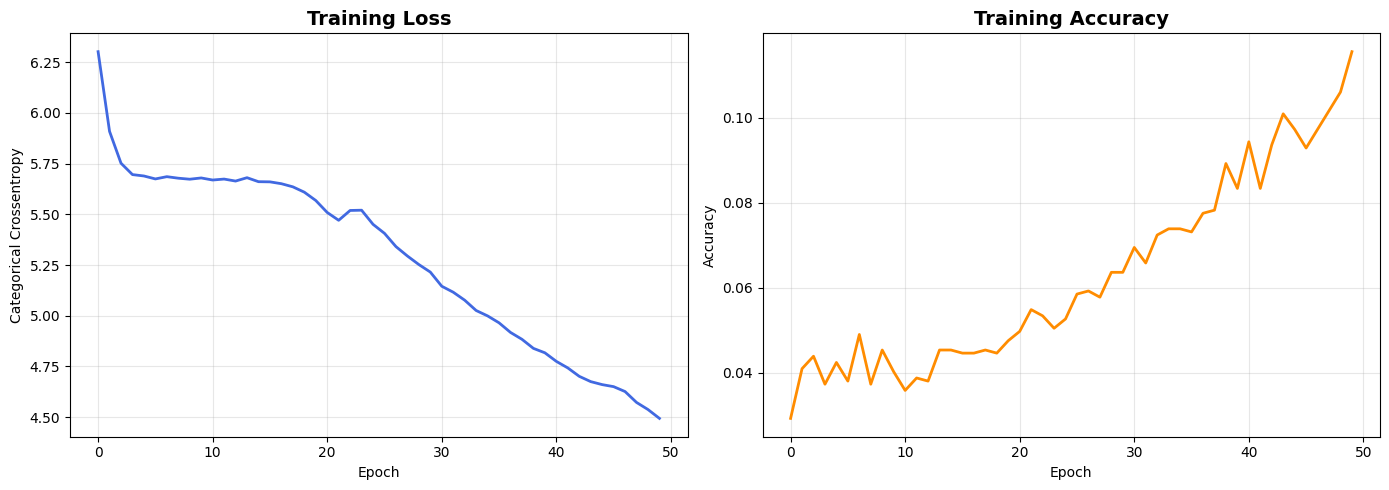

📈 Training curves saved!


In [7]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['loss'], color='royalblue', linewidth=2)
ax1.set_title('Training Loss', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Categorical Crossentropy')
ax1.grid(True, alpha=0.3)

ax2.plot(history.history['accuracy'], color='darkorange', linewidth=2)
ax2.set_title('Training Accuracy', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()
print('📈 Training curves saved!')

## Step 7: Deploy FastAPI Endpoint (Inside Colab)

In [8]:
# Write FastAPI app to file
api_code = '''
from fastapi import FastAPI
from fastapi.middleware.cors import CORSMiddleware
from pydantic import BaseModel
import numpy as np
import joblib
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences
from datetime import datetime

app = FastAPI(
    title="LSTM Text Prediction API",
    description="Predicts next words using a trained LSTM model",
    version="1.0.0"
)

app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],
    allow_methods=["*"],
    allow_headers=["*"]
)

# Load model and tokenizer
model = load_model("model/lstm_model.h5", compile=False)
tokenizer = joblib.load("model/tokenizer.pkl")
SEQ_LEN = 20

class PredictRequest(BaseModel):
    seed_text: str
    num_words: int = 5
    temperature: float = 1.0

class PredictResponse(BaseModel):
    seed_text: str
    predicted_text: str
    next_words: list
    timestamp: str

@app.get("/")
def root():
    return {"message": "LSTM Text Prediction API is running!", "status": "healthy"}

@app.post("/predict", response_model=PredictResponse)
def predict(request: PredictRequest):
    result = request.seed_text
    predicted_words = []

    for _ in range(request.num_words):
        token_list = tokenizer.texts_to_sequences([result.lower()])[0]
        token_list = token_list[-SEQ_LEN:]
        token_list = pad_sequences([token_list], maxlen=SEQ_LEN, padding="pre")

        preds = model.predict(token_list, verbose=0)[0]
        preds = np.log(preds + 1e-10) / request.temperature
        preds = np.exp(preds) / np.sum(np.exp(preds))
        predicted_index = np.random.choice(len(preds), p=preds)

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted_index:
                output_word = word
                break

        predicted_words.append(output_word)
        result += " " + output_word

    return PredictResponse(
        seed_text=request.seed_text,
        predicted_text=result,
        next_words=predicted_words,
        timestamp=datetime.utcnow().isoformat() + "Z"
    )

@app.get("/health")
def health():
    return {"status": "ok", "model": "lstm_text_prediction", "vocab_size": len(tokenizer.word_index)}
'''

with open('prediction_api.py', 'w') as f:
    f.write(api_code)

print('✅ FastAPI code written to prediction_api.py')

✅ FastAPI code written to prediction_api.py


In [ ]:
import os
os.kill(os.getpid(), 9)

In [1]:
import nest_asyncio
import uvicorn
import threading
from pyngrok import ngrok

nest_asyncio.apply()

# Kill previous
ngrok.kill()

def run_server():
    uvicorn.run('prediction_api:app', host='0.0.0.0', port=8000, log_level='error')

thread = threading.Thread(target=run_server, daemon=True)
thread.start()

import time
time.sleep(3)

# Apna token yahan paste karo
ngrok.set_auth_token("3CluLVaaFxpIM4SlZYoSn0c7HQn_62g3kwv6jbPnPFmZaUz4Z")

public_url = ngrok.connect(8000)
print(f'🌐 Public URL: {public_url}')
print(f'📖 Swagger UI: {public_url}/docs')

🌐 Public URL: NgrokTunnel: "https://stray-duplicate-maternal.ngrok-free.dev" -> "http://localhost:8000"
📖 Swagger UI: NgrokTunnel: "https://stray-duplicate-maternal.ngrok-free.dev" -> "http://localhost:8000"/docs


## Step 8: Test the API

In [2]:
import requests
import json

# Test local API
url = 'http://localhost:8000/predict'

payload = {
    "seed_text": "machine learning is a subset of artificial intelligence that",
    "num_words": 5,
    "temperature": 0.8
}

response = requests.post(url, json=payload)
result = response.json()

print('🧪 API Test Result:')
print(json.dumps(result, indent=2))

# Health check
health = requests.get('http://localhost:8000/health').json()
print('\n💚 Health Check:')
print(json.dumps(health, indent=2))

🧪 API Test Result:
{
  "seed_text": "machine learning is a subset of artificial intelligence that",
  "predicted_text": "machine learning is a subset of artificial intelligence that results years rnns statistics is",
  "next_words": [
    "results",
    "years",
    "rnns",
    "statistics",
    "is"
  ],
  "timestamp": "2026-04-23T19:33:29.777814Z"
}

💚 Health Check:
{
  "status": "ok",
  "model": "lstm_text_prediction",
  "vocab_size": 564
}


## Step 9: Download Model Files for Local Deployment

In [3]:
from google.colab import files
import zipfile
import os

# Zip model directory
with zipfile.ZipFile('lstm_model_package.zip', 'w') as zf:
    zf.write('model/lstm_model.h5')
    zf.write('model/tokenizer.pkl')
    zf.write('prediction_api.py')

files.download('lstm_model_package.zip')
print('✅ Model package downloaded!')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Model package downloaded!


---
## 📋 Dataset Declaration

| Field | Details |
|---|---|
| **Dataset Name** | Wikipedia Articles (AI/ML Topics) |
| **Source** | https://en.wikipedia.org |
| **API Used** | `wikipedia-api` Python library |
| **Topics Collected** | Machine Learning, AI, Deep Learning, Neural Networks, NLP, RNN, LSTM |
| **Total Words** | ~5,000–8,000 words |
| **Preprocessing Steps** | Lowercase, remove punctuation/numbers, tokenize, generate sliding window sequences of length 20 |
